### PARTE 2: Cenários, Dinamicidade e Tipos de Classe e Rede

#### 1.  Imports e carregamento dos dados

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import os

data_path = os.path.join('..', 'data', 'filtro04_processado.csv')

df = pd.read_csv(data_path)

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head(2)

Dataset carregado: 29 linhas x 36 colunas


,Title,Centralizado,Descentralizado,Distribuído,Hierárquico,Multidomínio,Paradigma Computacional,Técnica Computacional,Cenário de Aplicação,Estático,...,Usa Otimização,Abordagem,Família de Otimização,Subtipo de Metaheurística,Algoritmo Específico,Possui Link,Tipo do Artefato,Plataforma,URL,Unnamed: 35
0,Latency-aware network slicing for 5g urllc app...,1,0,0,0,0,Sistemas baseados em agentes,Reinforcement learning,Cirurgia remota;Telemedicina,0,...,Não,NaN,NaN,NaN,NaN,Não,NaN,NaN,NaN,0
1,Towards a european health data slice,0,0,1,0,0,Computação em névoa,Criptografia,Monitoramento de pacientes;Compartilhamento de...,0,...,Não,NaN,NaN,NaN,NaN,Não,NaN,NaN,NaN,0


#### 2.  Padronização global de estilo

In [11]:
PALETTE = [
    '#3A6B8A',
    '#C8773A',
    '#4A7C59',
    '#5C4E8A',
    '#7A9E9F',
]

HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    'custom_heatmap',
    [ "#6CB3DC", '#5C4E8A'],
    N=256
)

FIG_SIZE = (12, 6)

plt.rcParams.update({
    'font.family'                : 'serif',
    'font.serif'                 : ['Latin Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset'           : 'cm',
    'axes.formatter.use_mathtext': True,

    'font.size'       : 13,
    'axes.titlesize'  : 16,
    'axes.labelsize'  : 14,
    'xtick.labelsize' : 12,
    'ytick.labelsize' : 12,

    'axes.linewidth'    : 1.2,
    'xtick.major.width' : 1.1,
    'ytick.major.width' : 1.1,
    'xtick.major.size'  : 4,
    'ytick.major.size'  : 4,

    'axes.grid'        : False,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'savefig.bbox'     : 'tight',
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
})

print('✔  Estilo padronizado aplicado com sucesso.')

✔  Estilo padronizado aplicado com sucesso.


#### 3. Função auxiliar para gráfico de barras

In [12]:
def plot_bar(counts, title, xlabel, ylabel='',
             color_cycle=None, filename=None):
    """
    Parâmetros:
    -------------------------------------------------------------------------
    counts      : pd.Series  — index = categorias, values = contagens
    title       : str        — título do gráfico
    xlabel      : str        — rótulo do eixo X
    ylabel      : str        — rótulo do eixo Y (padrão 'Frequência')
    color_cycle : list       — lista de cores HEX (padrão: PALETTE global)
    filename    : str        — se informado, salva a figura em PNG
    """
    if color_cycle is None:
        color_cycle = PALETTE

    n      = len(counts)
    colors = [color_cycle[i % len(color_cycle)] for i in range(n)]

    fig, ax = plt.subplots(figsize=FIG_SIZE)

    bars = ax.bar(counts.index, counts.values,
                  color=colors, width=0.65,
                  edgecolor='white', linewidth=0.6)

    # rótulos sobre as barras
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + 0.12,
                str(int(h)),
                ha='center', va='bottom',
                fontsize=12)

    ax.set_title(title, pad=14)
    ax.set_xlabel(xlabel, labelpad=8)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    rotation = 35 if n > 4 else 0
    ha       = 'right' if n > 4 else 'center'
    ax.set_xticks(range(n))
    ax.set_xticklabels(counts.index, rotation=rotation, ha=ha)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

print('✔  Função plot_bar() definida.')

✔  Função plot_bar() definida.


#### 4. Figura 1: Cenários de Aplicação

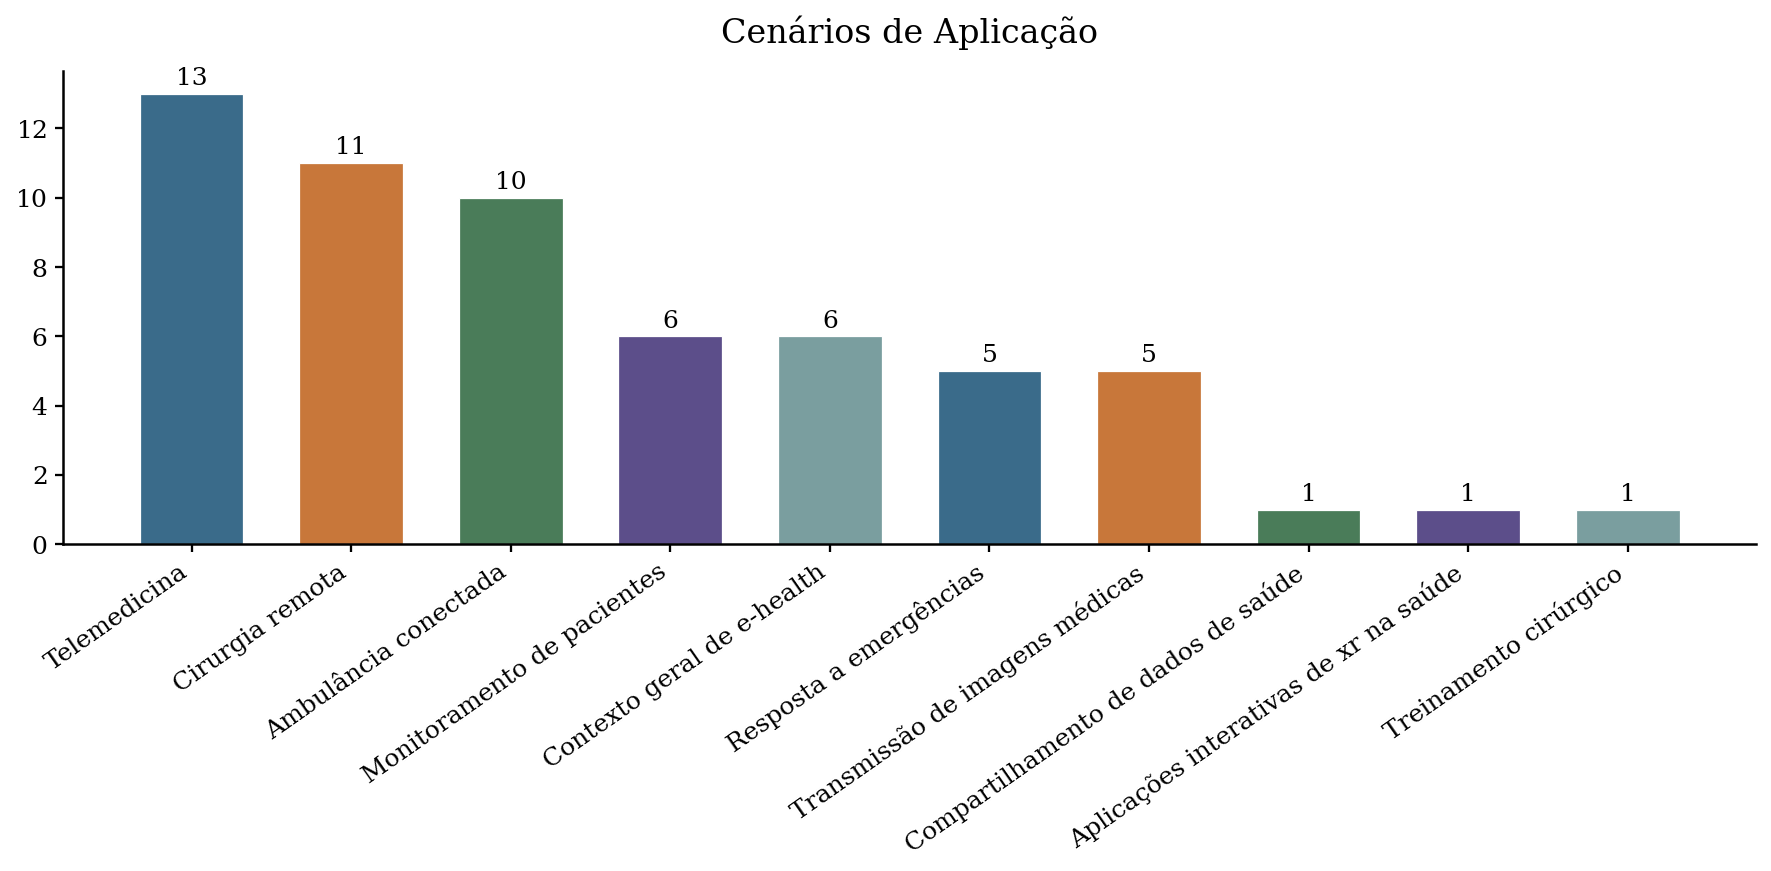

In [13]:
cenarios = (
    df['Cenário de Aplicação']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
)

plot_bar(
    counts = cenarios,
    title  = 'Cenários de Aplicação',
    xlabel = '',
)

#### 5. Figura 2: Dinamicidade do Cenário

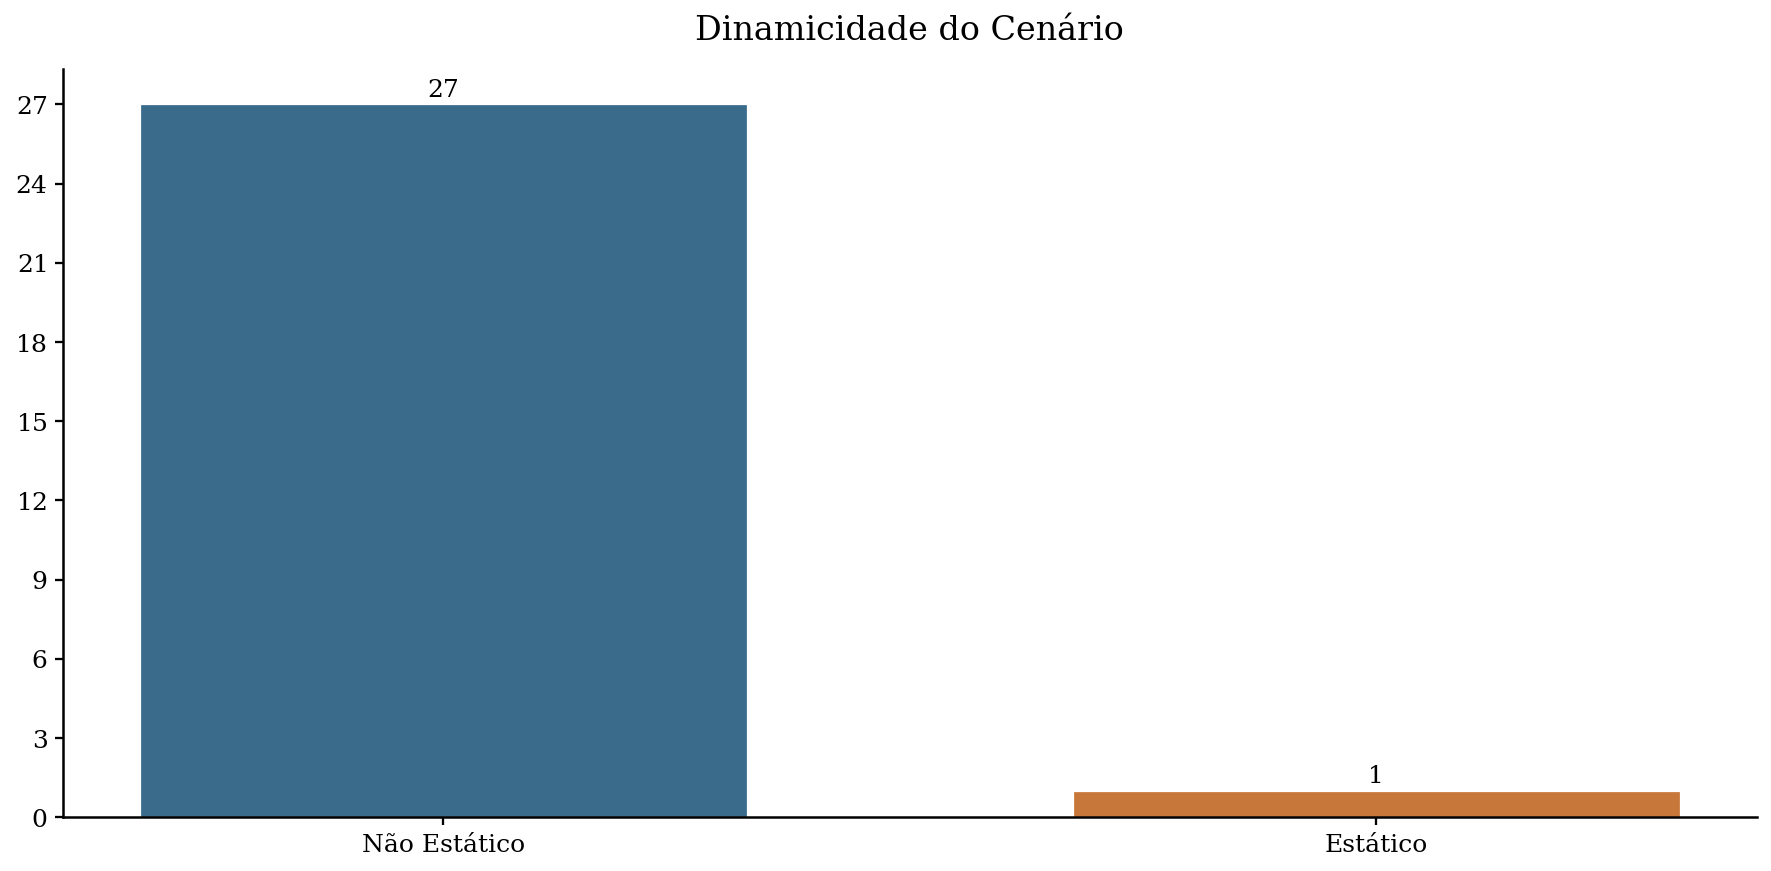

In [14]:
dinamicidade_cols = {
    'Estático'    : 'Estático',
    'Não Estático': 'Não Estático',
}

dinamicidade_counts = (
    df[list(dinamicidade_cols.keys())]
    .sum()
    .rename(index=dinamicidade_cols)
    .sort_values(ascending=False)
    .astype(int)
)

plot_bar(
    counts = dinamicidade_counts,
    title  = 'Dinamicidade do Cenário',
    xlabel = '',
)

#### 6. Figura 3: Tipo de Classe

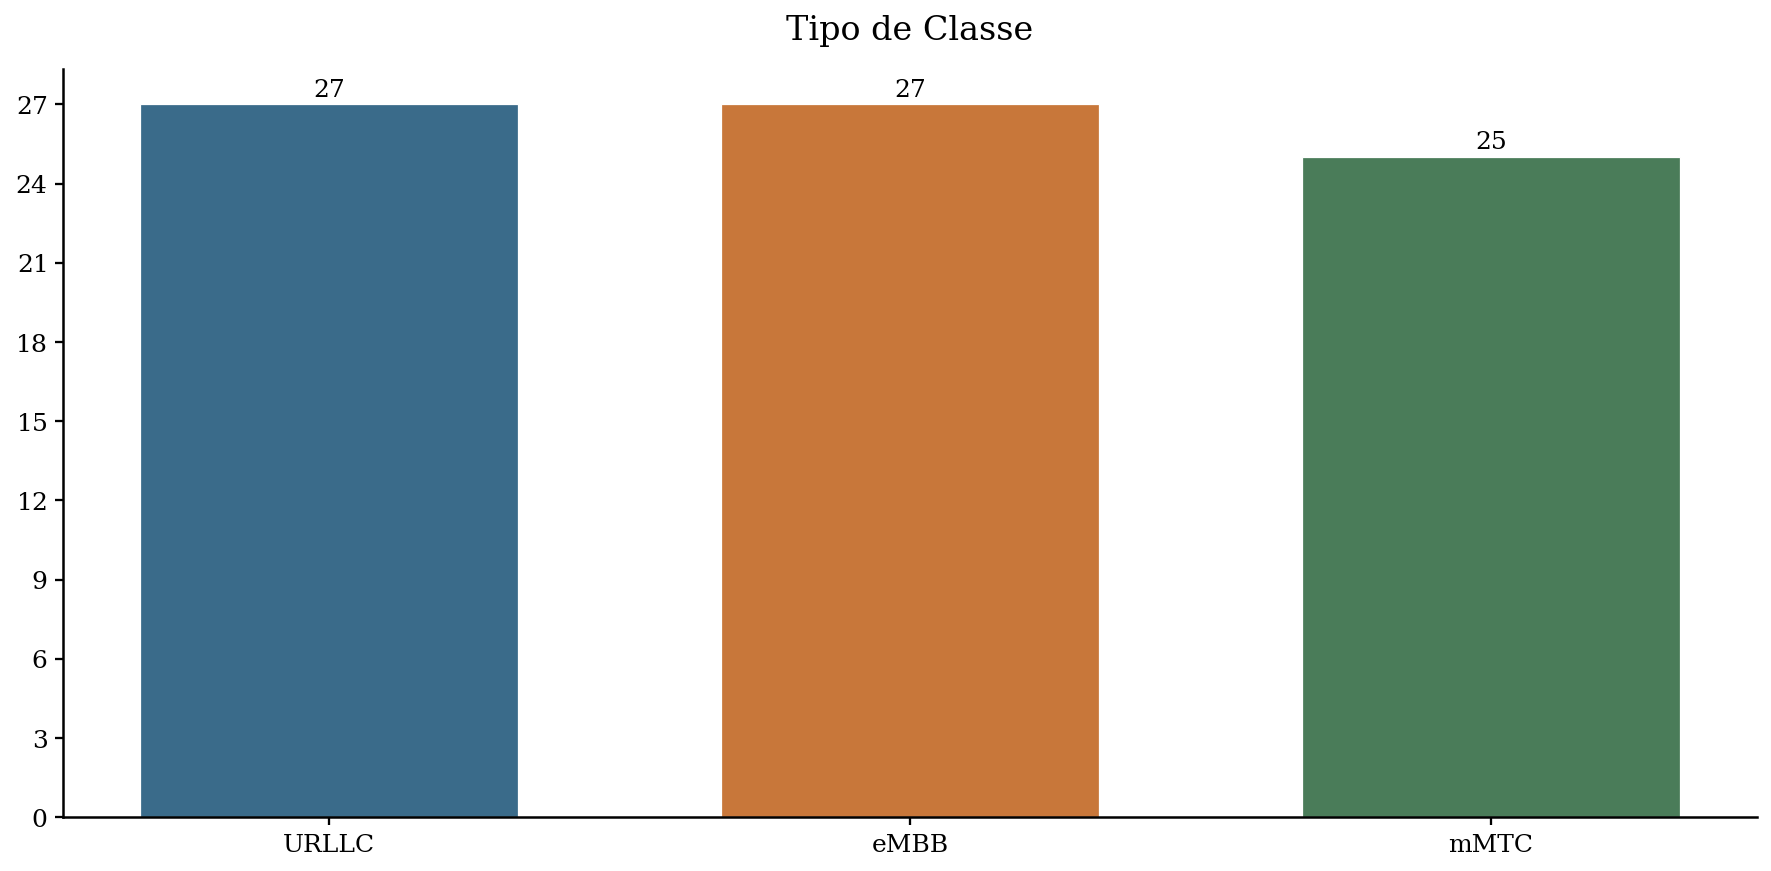

In [15]:
classe_cols = {
    'mMTC' : 'mMTC',
    'URLLC': 'URLLC',
    'eMBB' : 'eMBB',
}

classe_counts = (
    df[list(classe_cols.keys())]
    .sum()
    .rename(index=classe_cols)
    .sort_values(ascending=False)
    .astype(int)
)

plot_bar(
    counts = classe_counts,
    title  = 'Tipo de Classe',
    xlabel = '',
)

#### 7. Figura 4: Tipo de Rede

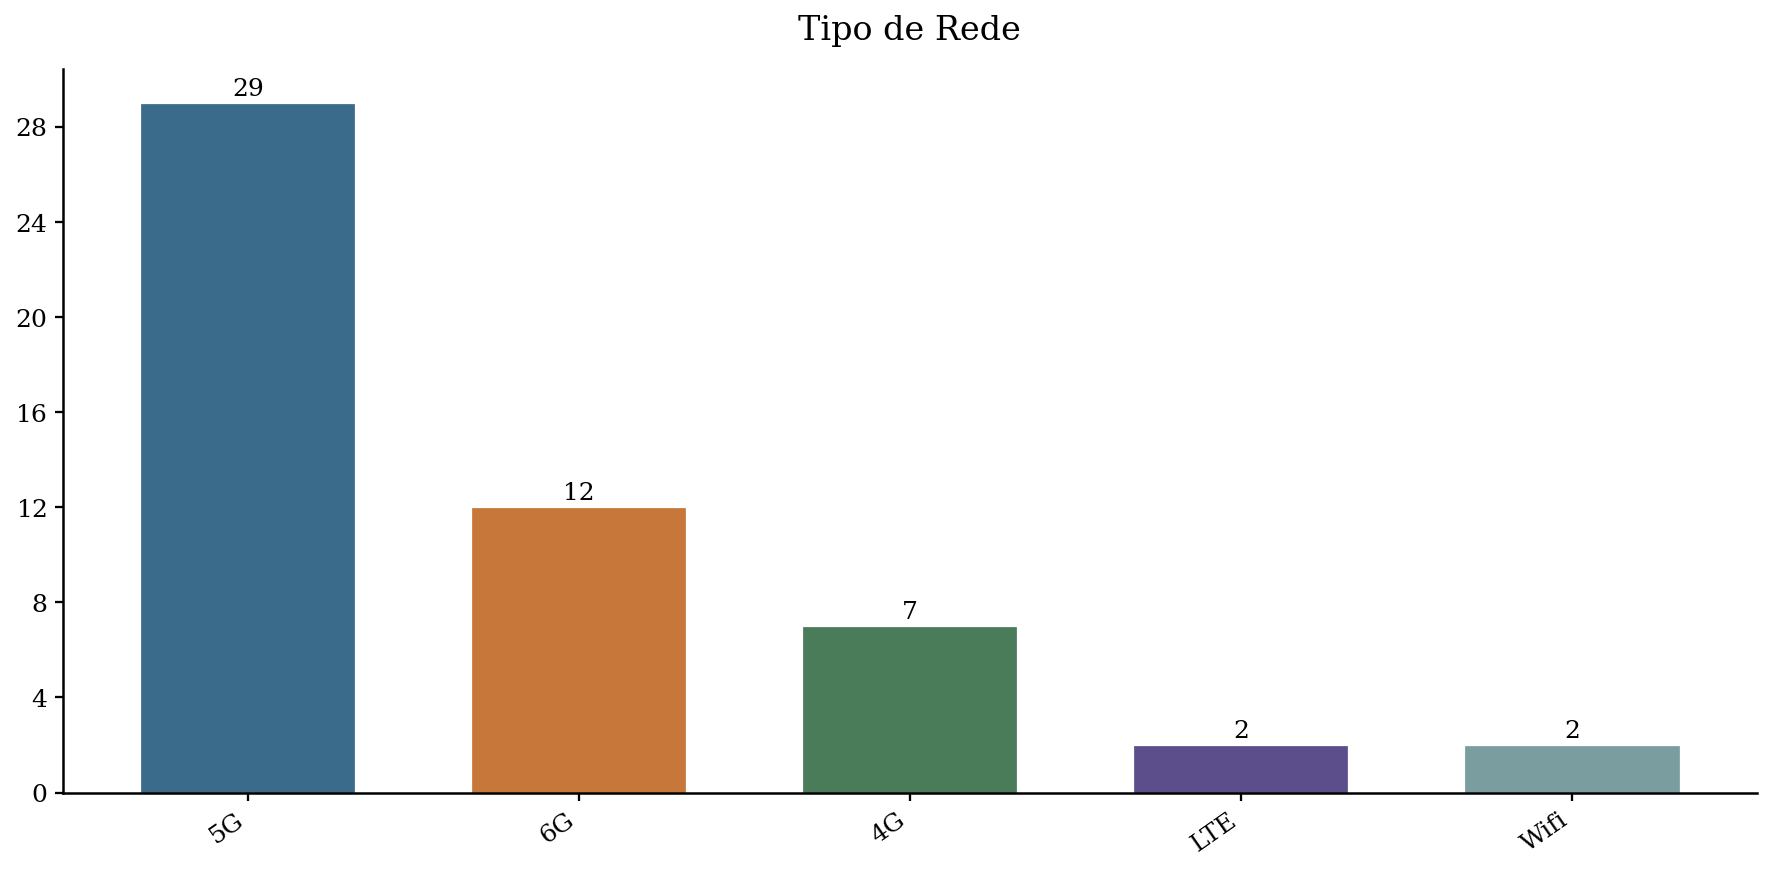

In [16]:
rede_cols = {
    'LTE' : 'LTE',
    '4G'  : '4G',
    '5G'  : '5G',
    '6G'  : '6G',
    'Wifi': 'Wifi',
}

rede_counts = (
    df[list(rede_cols.keys())]
    .sum()
    .rename(index=rede_cols)
    .sort_values(ascending=False)
    .astype(int)
)

plot_bar(
    counts = rede_counts,
    title  = 'Tipo de Rede',
    xlabel = '',
)

#### 8. Figura 5: Mapa de Calor — Cenários de Aplicação vs Tipo de Classe

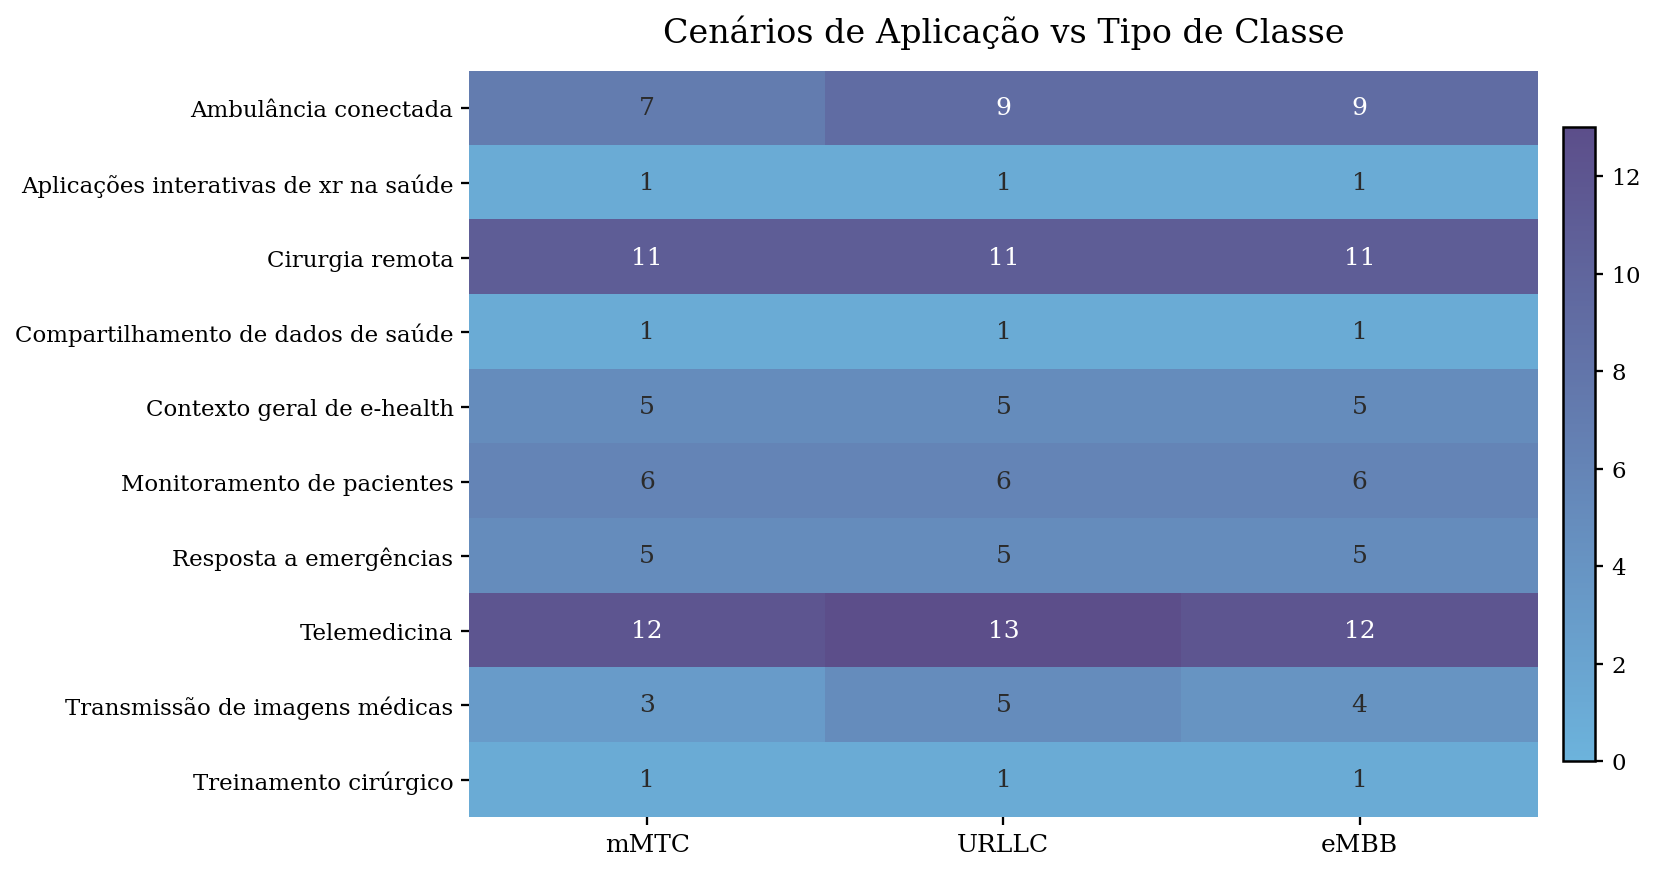

In [17]:
# 1. Explodir cenários com múltiplos valores
df_heat1 = df.copy()
df_heat1['Cenário de Aplicação'] = df_heat1['Cenário de Aplicação'].str.split(';')
df_heat1 = df_heat1.explode('Cenário de Aplicação')
df_heat1['Cenário de Aplicação'] = df_heat1['Cenário de Aplicação'].str.strip()

# 2. Colunas de classe
classe_labels = ['mMTC', 'URLLC', 'eMBB']

# 3. Formato longo
df_melt1 = df_heat1.melt(
    id_vars    = 'Cenário de Aplicação',
    value_vars = classe_labels,
    var_name   = 'Classe',
    value_name = 'Presente',
)
df_melt1 = df_melt1[df_melt1['Presente'] == 1]

# 4. Pivot
heat1 = (
    df_melt1
    .groupby(['Cenário de Aplicação', 'Classe'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=classe_labels, fill_value=0)
)

# 5. Plot
fig, ax = plt.subplots(figsize=FIG_SIZE)

im = ax.imshow(heat1.values, aspect='auto', cmap=HEATMAP_CMAP, vmin=0)

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('', fontsize=13)
cbar.ax.tick_params(labelsize=11)

ax.set_xticks(range(len(classe_labels)))
ax.set_xticklabels(classe_labels, rotation=0, ha='center', fontsize=12)

ax.set_yticks(range(len(heat1.index)))
ax.set_yticklabels(heat1.index, fontsize=11)

ax.set_xlabel('', labelpad=8, fontsize=14)
ax.set_ylabel('', labelpad=8, fontsize=14)
ax.set_title('Cenários de Aplicação vs Tipo de Classe', pad=14, fontsize=16)

for i in range(heat1.shape[0]):
    for j in range(heat1.shape[1]):
        val      = heat1.values[i, j]
        norm_val = val / (heat1.values.max() or 1)
        txt_color = 'white' if norm_val > 0.55 else '#2B2B2B'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=12, color=txt_color)

ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()

#### 9. Figura 6: Mapa de Calor — Cenários de Aplicação vs Tipo de Rede

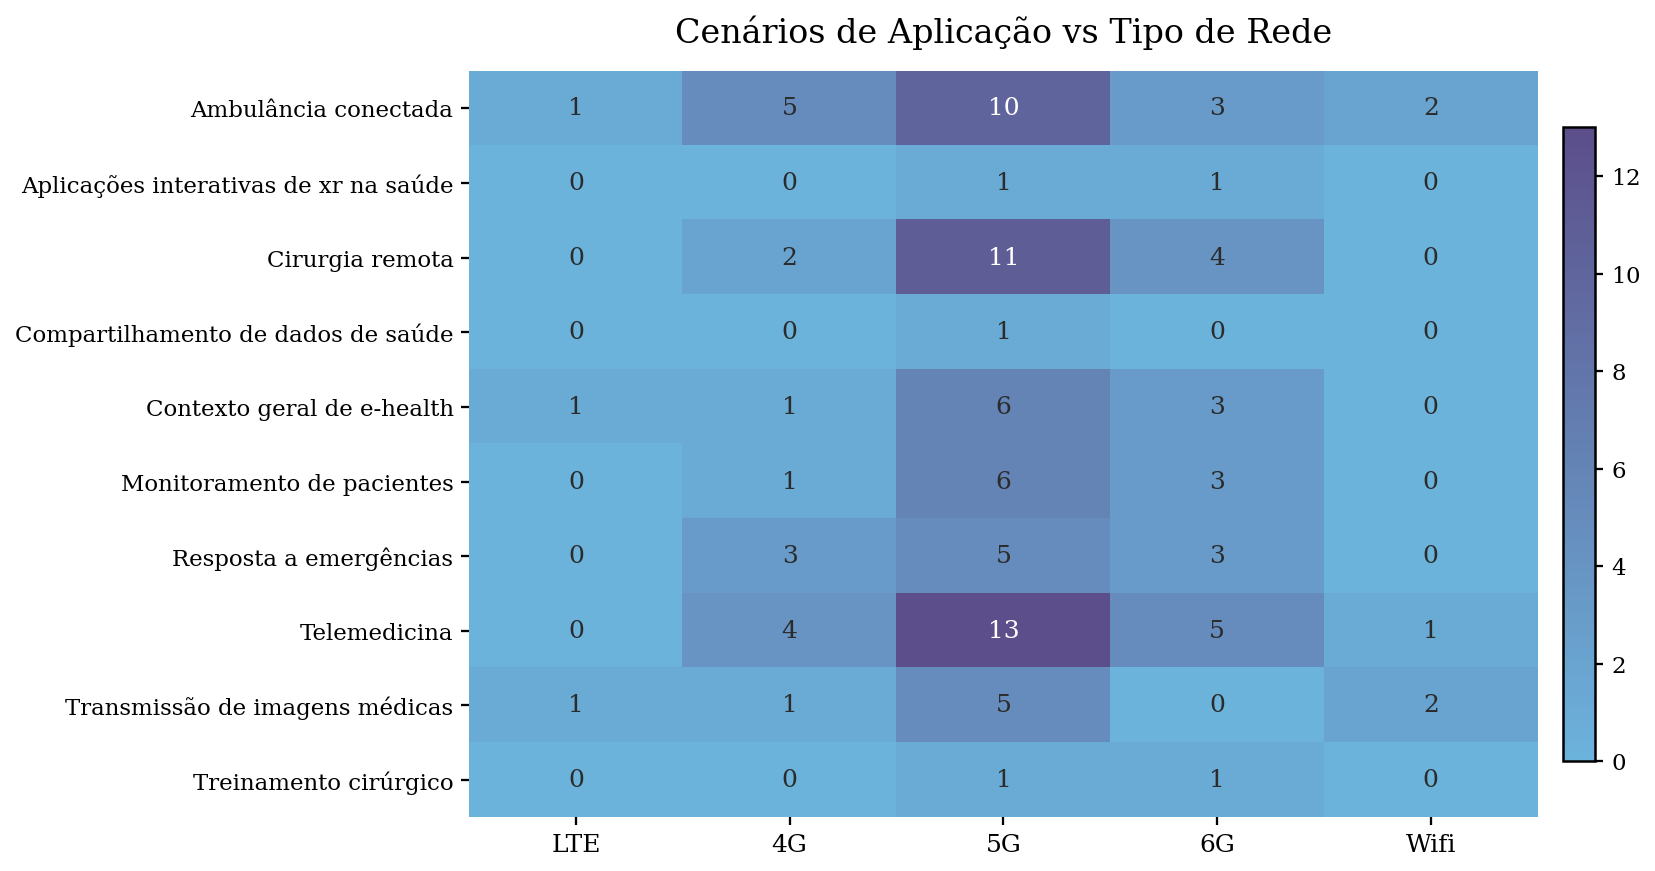

In [18]:
# 1. Explodir cenários com múltiplos valores
df_heat2 = df.copy()
df_heat2['Cenário de Aplicação'] = df_heat2['Cenário de Aplicação'].str.split(';')
df_heat2 = df_heat2.explode('Cenário de Aplicação')
df_heat2['Cenário de Aplicação'] = df_heat2['Cenário de Aplicação'].str.strip()

# 2. Colunas de rede
rede_labels = ['LTE', '4G', '5G', '6G', 'Wifi']

# 3. Formato longo
df_melt2 = df_heat2.melt(
    id_vars    = 'Cenário de Aplicação',
    value_vars = rede_labels,
    var_name   = 'Rede',
    value_name = 'Presente',
)
df_melt2 = df_melt2[df_melt2['Presente'] == 1]

# 4. Pivot
heat2 = (
    df_melt2
    .groupby(['Cenário de Aplicação', 'Rede'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=rede_labels, fill_value=0)
)

# 5. Plot
fig, ax = plt.subplots(figsize=FIG_SIZE)

im = ax.imshow(heat2.values, aspect='auto', cmap=HEATMAP_CMAP, vmin=0)

cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('', fontsize=13)
cbar.ax.tick_params(labelsize=11)

ax.set_xticks(range(len(rede_labels)))
ax.set_xticklabels(rede_labels, rotation=0, ha='center', fontsize=12)

ax.set_yticks(range(len(heat2.index)))
ax.set_yticklabels(heat2.index, fontsize=11)

ax.set_xlabel('', labelpad=8, fontsize=14)
ax.set_ylabel('', labelpad=8, fontsize=14)
ax.set_title('Cenários de Aplicação vs Tipo de Rede', pad=14, fontsize=16)

for i in range(heat2.shape[0]):
    for j in range(heat2.shape[1]):
        val      = heat2.values[i, j]
        norm_val = val / (heat2.values.max() or 1)
        txt_color = 'white' if norm_val > 0.55 else '#2B2B2B'
        ax.text(j, i, str(val), ha='center', va='center', fontsize=12, color=txt_color)

ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()